# State Space Model

A simple linear line fit example, showing the difference between regression and state space.

## Data Generation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def generate_dynamic_data(n=50, slope_drift=0.05, obs_noise=2.0):
    np.random.seed(42)
    
    # Initialize containers
    y = np.zeros(n)
    levels = np.zeros(n)
    slopes = np.zeros(n)
    
    # 1. Initial conditions (intercept and starting slope)
    levels[0] = 10
    slopes[0] = 0.5
    y[0] = levels[0] + np.random.normal(0, obs_noise)
    
    # 2. Evolve the system
    for t in range(1, n):
        # Slope evolves: m_t = m_{t-1} + shock
        slopes[t] = slopes[t-1] + np.random.normal(0, slope_drift)
        
        # Level evolves: c_t = c_{t-1} + m_{t-1}
        levels[t] = levels[t-1] + slopes[t-1]
        
        # Observation: y_t = c_t + noise
        y[t] = levels[t] + np.random.normal(0, obs_noise)
        
    return y, levels, slopes

# Usage
y, true_levels, true_slopes = generate_dynamic_data(n=100, slope_drift=0.08)

## Constant Slope

In [2]:
n=50
y, true_level, true_slope = generate_dynamic_data(n=50, slope_drift=0)

### State Space Parameters

In [3]:

# Transition Matrix (T): Level_t = Level_t-1 + Slope_t-1; Slope_t = Slope_t-1
T = np.array([[1, 1],
              [0, 1]])
# --- How do we expect things to change step to step ----

# Observation Matrix (Z): y_t = 1*Level_t + 0*Slope_t
Z = np.array([[1, 0]])
# --- From our state vector, what do we observe and how (state vector to observation) ---

# Covariances (Q = Process Noise, H = Measurement Noise)
Q = np.array([
    [0.1, 0.0], # Level can shift by ~0.3 units (sqrt of 0.1)
    [0.0, 0.01] # Slope can shift by ~0.1 units
])
H = np.array([[4.0]]) # Expecting noise in our revenue data (sigma^2)

# Initialize States, Initial guess for [Level, Slope]
alpha = np.array([0, 0])      

# High initial uncertainty -> Large Kalman gain, i.e each data point quickly changes the models parameters
P = np.eye(2) * 1000          

### Run Model and Store Matrixes

In [4]:
filtered_states = []
P_history = []       # Stores updated uncertainty (P)
P_pred_history = []  # Stores predicted uncertainty (P_pred)

for t in range(n):
    # --- PREDICT ---
    alpha_pred = T @ alpha
    P_pred = T @ P @ T.T + Q
    
    # Store the prediction for the smoother
    P_pred_history.append(P_pred)
    
    # --- UPDATE ---
    residual = y[t] - (Z @ alpha_pred)
    S = Z @ P_pred @ Z.T + H
    K = P_pred @ Z.T @ np.linalg.inv(S)
    
    alpha = alpha_pred + K @ residual
    P = (np.eye(2) - K @ Z) @ P_pred
    
    # Store the updated values
    filtered_states.append(alpha)
    P_history.append(P)

# Convert to arrays for easier indexing
filtered_states = np.array(filtered_states)
P_history = np.array(P_history)
P_pred_history = np.array(P_pred_history)

### Smooth results

The smoother calculates a Smoothing Gain ($J_t$). It basically asks: "How much did my prediction for tomorrow ($t+1$) change once I actually saw the data for tomorrow? I should apply a portion of that change back to my estimate for today ($t$)."

In [5]:

smoothed_states = np.zeros_like(filtered_states)
smoothed_states[-1] = filtered_states[-1] # Start at the end

# Step backward from n-2 down to 0
for t in range(n - 2, -1, -1):
    # Calculate the Smoother Gain
    # J = P_filtered_today @ T.T @ inv(P_predicted_tomorrow)
    J = P_history[t] @ T.T @ np.linalg.inv(P_pred_history[t+1])
    
    # Update the state: Today_smoothed = Today_filtered + J * (Tomorrow_smoothed - Tomorrow_predicted)
    smoothed_states[t] = filtered_states[t] + J @ (smoothed_states[t+1] - (T @ filtered_states[t]))

# smoothed_states now contains the 'de-noised' Level and Slope for every day

### Regression fit

In [6]:
m, c = np.polyfit(np.arange(n), y, deg=1)

f = lambda x: m*x + c  # noqa: E731
regression = f(np.arange(n))

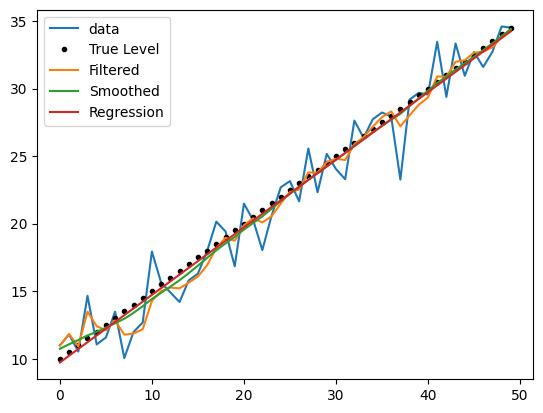

In [7]:
plt.plot(y, label = 'data')
plt.plot(true_level, "k.", label = "True Level")
plt.plot(filtered_states[:,0], label = "Filtered") # only first index as its our level, 2nd is our slope
plt.plot(smoothed_states[:,0], label = "Smoothed")
plt.plot(regression, label="Regression")
plt.legend()

## Time Varying Slope

In [8]:
n=50
y, true_level, true_slope = generate_dynamic_data(n=50, slope_drift=0.1, obs_noise=1)

In [9]:

# Transition Matrix (T): Level_t = Level_t-1 + Slope_t-1; Slope_t = Slope_t-1
T = np.array([[1, 1],
              [0, 1]])
# --- How do we expect things to change step to step ----

# Observation Matrix (Z): y_t = 1*Level_t + 0*Slope_t
Z = np.array([[1, 0]])
# --- From our state vector, what do we observe and how (state vector to observation) ---

# Covariances (Q = Process Noise, H = Measurement Noise)
Q = np.array([
    [0.1, 0.0], # Level can shift by ~0.3 units (sqrt of 0.1)
    [0.0, 0.01] # Slope can shift by ~0.1 units
])
H = np.array([[4.0]]) # Expecting noise in our revenue data (sigma^2)

# Initialize States, Initial guess for [Level, Slope]
alpha = np.array([0, 0])      

# High initial uncertainty -> Large Kalman gain, i.e each data point quickly changes the models parameters
P = np.eye(2) * 1000          

In [10]:
filtered_states = []
P_history = []       # Stores updated uncertainty (P)
P_pred_history = []  # Stores predicted uncertainty (P_pred)

for t in range(n):
    # --- PREDICT ---
    alpha_pred = T @ alpha
    P_pred = T @ P @ T.T + Q
    
    # Store the prediction for the smoother
    P_pred_history.append(P_pred)
    
    # --- UPDATE ---
    residual = y[t] - (Z @ alpha_pred)
    S = Z @ P_pred @ Z.T + H
    K = P_pred @ Z.T @ np.linalg.inv(S)
    
    alpha = alpha_pred + K @ residual
    P = (np.eye(2) - K @ Z) @ P_pred
    
    # Store the updated values
    filtered_states.append(alpha)
    P_history.append(P)

# Convert to arrays for easier indexing
filtered_states = np.array(filtered_states)
P_history = np.array(P_history)
P_pred_history = np.array(P_pred_history)

In [11]:

smoothed_states = np.zeros_like(filtered_states)
smoothed_states[-1] = filtered_states[-1] # Start at the end

# Step backward from n-2 down to 0
for t in range(n - 2, -1, -1):
    # Calculate the Smoother Gain
    # J = P_filtered_today @ T.T @ inv(P_predicted_tomorrow)
    J = P_history[t] @ T.T @ np.linalg.inv(P_pred_history[t+1])
    
    # Update the state: Today_smoothed = Today_filtered + J * (Tomorrow_smoothed - Tomorrow_predicted)
    smoothed_states[t] = filtered_states[t] + J @ (smoothed_states[t+1] - (T @ filtered_states[t]))

# smoothed_states now contains the 'de-noised' Level and Slope for every day

In [12]:
m, c = np.polyfit(np.arange(n), y, deg=1)

f = lambda x: m*x + c  # noqa: E731
regression = f(np.arange(n))

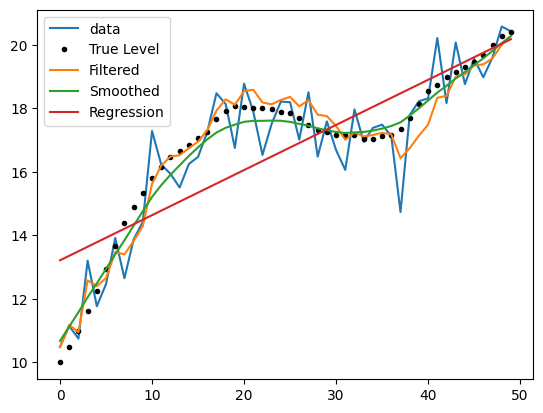

In [13]:
plt.plot(y, label = 'data')
plt.plot(true_level, "k.", label = "True Level")
plt.plot(filtered_states[:,0], label = "Filtered") # only first index as its our level, 2nd is our slope
plt.plot(smoothed_states[:,0], label = "Smoothed")
plt.plot(regression, label="Regression")
plt.legend()

## Level Shocks

In [14]:
n=50
y, true_level, true_slope = generate_dynamic_data(n=50, slope_drift=0.1, obs_noise=1)
true_level[len(y)//2:] += 10
y[len(y)//2:] += 10

In [15]:

# Transition Matrix (T): Level_t = Level_t-1 + Slope_t-1; Slope_t = Slope_t-1
T = np.array([[1, 1],
              [0, 1]])
# --- How do we expect things to change step to step ----

# Observation Matrix (Z): y_t = 1*Level_t + 0*Slope_t
Z = np.array([[1, 0]])
# --- From our state vector, what do we observe and how (state vector to observation) ---

# Covariances (Q = Process Noise, H = Measurement Noise)
Q = np.array([
    [5, 0.0], # Level can shift by ~0.3 units (sqrt of 0.1)
    [0.0, 0.01] # Slope can shift by ~0.1 units
])
H = np.array([[8]]) # Expecting noise in our revenue data (sigma^2)

# Initialize States, Initial guess for [Level, Slope]
alpha = np.array([0, 0])      

# High initial uncertainty -> Large Kalman gain, i.e each data point quickly changes the models parameters
P = np.eye(2) * 1000          

In [16]:
filtered_states = []
P_history = []       # Stores updated uncertainty (P)
P_pred_history = []  # Stores predicted uncertainty (P_pred)

for t in range(n):
    # --- PREDICT ---
    alpha_pred = T @ alpha
    P_pred = T @ P @ T.T + Q
    
    # Store the prediction for the smoother
    P_pred_history.append(P_pred)
    
    # --- UPDATE ---
    residual = y[t] - (Z @ alpha_pred)
    S = Z @ P_pred @ Z.T + H
    K = P_pred @ Z.T @ np.linalg.inv(S)
    
    alpha = alpha_pred + K @ residual
    P = (np.eye(2) - K @ Z) @ P_pred
    
    # Store the updated values
    filtered_states.append(alpha)
    P_history.append(P)

# Convert to arrays for easier indexing
filtered_states = np.array(filtered_states)
P_history = np.array(P_history)
P_pred_history = np.array(P_pred_history)

In [17]:

smoothed_states = np.zeros_like(filtered_states)
smoothed_states[-1] = filtered_states[-1] # Start at the end

# Step backward from n-2 down to 0
for t in range(n - 2, -1, -1):
    # Calculate the Smoother Gain
    # J = P_filtered_today @ T.T @ inv(P_predicted_tomorrow)
    J = P_history[t] @ T.T @ np.linalg.inv(P_pred_history[t+1])
    
    # Update the state: Today_smoothed = Today_filtered + J * (Tomorrow_smoothed - Tomorrow_predicted)
    smoothed_states[t] = filtered_states[t] + J @ (smoothed_states[t+1] - (T @ filtered_states[t]))

# smoothed_states now contains the 'de-noised' Level and Slope for every day

In [18]:
m, c = np.polyfit(np.arange(n), y, deg=1)

f = lambda x: m*x + c  # noqa: E731
regression = f(np.arange(n))

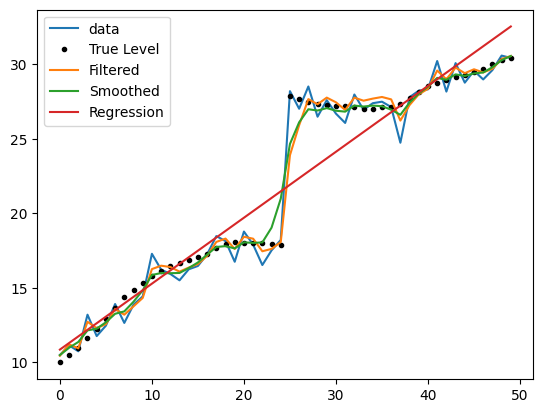

In [19]:
plt.plot(y, label = 'data')
plt.plot(true_level, "k.", label = "True Level")
plt.plot(filtered_states[:,0], label = "Filtered") # only first index as its our level, 2nd is our slope
plt.plot(smoothed_states[:,0], label = "Smoothed")
plt.plot(regression, label="Regression")
plt.legend()

When you include both high $Q[0,0]$ (level shocks) and high $H$ (observation noise), the Kalman Filter faces a dilemma: "Is this spike a one-day glitch or a permanent shift?"If you set $Q[0,0]$ too high, your "Smoothed Level" will be very wiggly and follow the noise too closely (overfitting).If you set $H$ too high, your "Smoothed Level" will be a stiff straight line and ignore real, permanent shifts in your revenue (underfitting).

In [101]:
smoothed_states[-1,:]

array([30.54806946,  0.35857613])

In [102]:
filtered_states[-1,:]

array([30.54806946,  0.35857613])